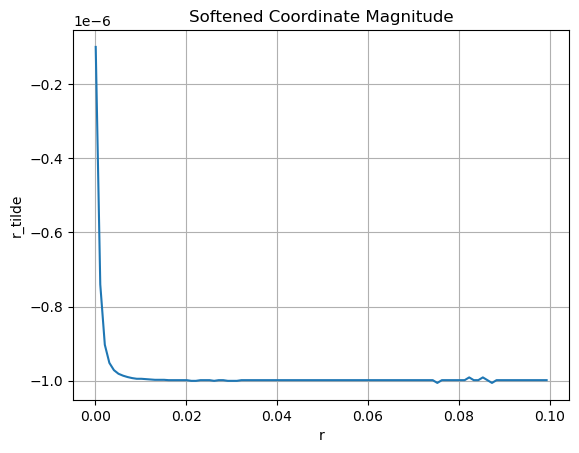

In [48]:
import torch


def smoothstep5(x: torch.Tensor) -> torch.Tensor:
    x = torch.clamp(x, 0.0, 1.0)
    return x * x * x * (10.0 + x * (-15.0 + 6.0 * x))


def soften_coordinates_piecewise(
    x: torch.Tensor,
    eps: float = 1e-3,
    r_in: float = 0.05,
    r_out: float = 0.15,
    tiny: float = 1e-12,
) -> torch.Tensor:
    """
    对 (N, 3) 坐标/向量做分段短程软化。
    r <= r_in   : 完全使用 soft 模长
    r >= r_out  : 完全保持原模长
    中间区域     : 五次 smoothstep 平滑过渡
    """
    assert r_out > r_in

    r2 = (x * x).sum(dim=-1, keepdim=True)
    r = torch.sqrt(r2 + tiny)
    r_soft = torch.sqrt(r2 + eps * eps)

    t = (r - r_in) / (r_out - r_in)
    s = smoothstep5(t)
    w = 1.0 - s

    r_tilde = w * r_soft + (1.0 - w) * r
    scale = r_tilde / (r + tiny)
    x_tilde = x * scale
    return x_tilde

x = torch.linspace(1e-4,0.1,300).reshape(-1,3)
y = soften_coordinates_piecewise(x.unsqueeze(-1),tiny=1e-6).squeeze(-1)
# print(x.shape, y.shape)
# y.norm(dim=1,p=2).sum().backward()
# # print(x.grad)
# x_2 = torch.linspace(1e-4,0.1,300).reshape(-1,3).requires_grad_(True)
# x_2.norm(dim=1,p=2).sum().backward()
# print(x_2.grad-x.grad)
import matplotlib.pyplot as plt
plt.plot(x[:, 0], y[:,0]-x[:,0], label='Softened')
# plt.plot(x.flatten(), x.flatten(), '--', label='Identity')
plt.xlabel('r')
plt.ylabel('r_tilde')
plt.title('Softened Coordinate Magnitude')
plt.grid()
plt.show()